# Exploratory Data Analysis

In [134]:
#Importing essential libraries
from openpyxl import load_workbook
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#Libraries for machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler


## Loading PCOS Dataset 

In [135]:
#Loading the excel file
pcos_wb = load_workbook("PCOS Dataset.xlsx")

#Selecting the active sheet 
pcos_ws = pcos_wb.active

#Taking all rows as a list of list/tuples 
pcos_data = list(pcos_ws.iter_rows(values_only=True))

#Seperating the header from the actual data rows
headers = pcos_data[0]
data_rows = pcos_data[1:]

#Creating a pandas dataframe
pcos_df = pd.DataFrame(data_rows, columns=headers)

#Priting the table
print(pcos_df.to_string())

#Reading data from the cells
#for row in pcos_ws.iter_rows(values_only=True):
#    print(row)

     Age  Height_cm  Weight_kg    BMI  Waist_Circumference_cm  Hip_Circumference_cm  Waist_Hip_Ratio  Age_at_Menarche  Menstrual_Cycle_Length_days  Menstrual_Irregularity  Gravidity  Parity  Hirsutism_Score_FG  Acne_Severity  Alopecia  Skin_Darkening_Acanthosis  Blood_Pressure_Systolic  Blood_Pressure_Diastolic  Physical_Activity_Level  Smoking_Status  Alcohol_Intake  Dietary_Sugar_Intake  Sleep_Hours  FSH_mIU_mL  LH_mIU_mL  LH_FSH_Ratio  Total_Testosterone_ng_dL  Free_Testosterone_pg_mL  DHEAS_ug_dL  Prolactin_ng_mL  Estradiol_pg_mL  Progesterone_ng_mL  SHBG_nmol_L  Fasting_Glucose_mg_dL  Fasting_Insulin_uIU_mL  HOMA_IR  HbA1c_percent  Total_Cholesterol_mg_dL  HDL_mg_dL  LDL_mg_dL  Triglycerides_mg_dL  Ovary_Volume_Left_cm3  Ovary_Volume_Right_cm3  Follicle_Count_Left  Follicle_Count_Right  CRP_mg_L  ALT_U_L  AST_U_L  TSH_uIU_mL  Vitamin_D_ng_mL  Hemoglobin_g_dL  PCOS_Diagnosis
0     39      152.1       63.4  25.82                    93.1                  91.5             0.86        

## Viewing List of Feature Names

In [136]:
#Viewing all feature names

#Loading the excel file
df = pd.read_excel("PCOS Dataset.xlsx")

#Extracting the column names
feature_names = df.columns.tolist()

#Printing the feature names
print(f"Total features: {len(feature_names)}\n")
for feature in feature_names:
    print(f"'{feature}',")

Total features: 52

'Age',
'Height_cm',
'Weight_kg',
'BMI',
'Waist_Circumference_cm',
'Hip_Circumference_cm',
'Waist_Hip_Ratio',
'Age_at_Menarche',
'Menstrual_Cycle_Length_days',
'Menstrual_Irregularity',
'Gravidity',
'Parity',
'Hirsutism_Score_FG',
'Acne_Severity',
'Alopecia',
'Skin_Darkening_Acanthosis',
'Blood_Pressure_Systolic',
'Blood_Pressure_Diastolic',
'Physical_Activity_Level',
'Smoking_Status',
'Alcohol_Intake',
'Dietary_Sugar_Intake',
'Sleep_Hours',
'FSH_mIU_mL',
'LH_mIU_mL',
'LH_FSH_Ratio',
'Total_Testosterone_ng_dL',
'Free_Testosterone_pg_mL',
'DHEAS_ug_dL',
'Prolactin_ng_mL',
'Estradiol_pg_mL',
'Progesterone_ng_mL',
'SHBG_nmol_L',
'Fasting_Glucose_mg_dL',
'Fasting_Insulin_uIU_mL',
'HOMA_IR',
'HbA1c_percent',
'Total_Cholesterol_mg_dL',
'HDL_mg_dL',
'LDL_mg_dL',
'Triglycerides_mg_dL',
'Ovary_Volume_Left_cm3',
'Ovary_Volume_Right_cm3',
'Follicle_Count_Left',
'Follicle_Count_Right',
'CRP_mg_L',
'ALT_U_L',
'AST_U_L',
'TSH_uIU_mL',
'Vitamin_D_ng_mL',
'Hemoglobin_g_dL',
'PCOS_Di

## Creating a reduced copy of the PCOS dataframe with only the essential features

In [137]:
#Reduced Dataset

essential_features = [
    'Menstrual_Cycle_Length_days',
    'Menstrual_Irregularity',
    'BMI',
    'Fasting_Glucose_mg_dL',
    'Fasting_Insulin_uIU_mL',
    'HOMA_IR',
    'LH_mIU_mL',
    'FSH_mIU_mL',
    'LH_FSH_Ratio',
    'Total_Testosterone_ng_dL',
    'Free_Testosterone_pg_mL',
    'Total_Cholesterol_mg_dL',
    'HDL_mg_dL',
    'LDL_mg_dL',
    'Triglycerides_mg_dL',
    'Dietary_Sugar_Intake',
    'Physical_Activity_Level',
    'PCOS_Diagnosis', 
    'Hirsutism_Score_FG',
    'Acne_Severity',
    'Alopecia',
    'Skin_Darkening_Acanthosis',
    'Vitamin_D_ng_mL'
]

df_2 = df[essential_features].copy()

df_2.head()

,Menstrual_Cycle_Length_days,Menstrual_Irregularity,BMI,Fasting_Glucose_mg_dL,Fasting_Insulin_uIU_mL,HOMA_IR,LH_mIU_mL,FSH_mIU_mL,LH_FSH_Ratio,Total_Testosterone_ng_dL,Free_Testosterone_pg_mL,Total_Cholesterol_mg_dL,HDL_mg_dL,LDL_mg_dL,Triglycerides_mg_dL,Dietary_Sugar_Intake,Physical_Activity_Level,PCOS_Diagnosis,Hirsutism_Score_FG,Acne_Severity,Alopecia,Skin_Darkening_Acanthosis,Vitamin_D_ng_mL
0,33,0,25.82,96.7,17.87,1.94,7.40,4.77,1.33,52.1,8.42,142,27,97,299,2,2,1,17,2,0,0,46.3
1,26,1,31.36,115.0,18.86,2.70,16.14,5.49,1.29,79.1,8.25,186,58,86,131,1,2,0,20,3,0,1,24.8
2,38,0,22.90,75.0,15.61,6.00,-0.38,8.10,1.43,59.4,3.87,138,30,162,103,1,1,0,11,2,0,0,22.2
3,31,1,23.68,106.2,14.21,2.99,13.85,9.88,1.39,83.5,2.30,94,53,122,179,3,1,0,9,0,1,0,18.9
4,32,0,29.05,91.9,15.21,3.78,14.03,8.42,1.92,44.8,3.72,208,70,55,137,3,2,0,24,1,0,0,46.4


### Viewing information about the features

In [138]:
#Viewing the split between PCOS and non PCOS patients
PCOS_patient_count = (df_2['PCOS_Diagnosis'] == 1).sum()
nonPCOS_patient_count = (df_2['PCOS_Diagnosis'] == 0).sum()

#Calculating percentages of each quantity
PCOS_percentage = ( PCOS_patient_count / 468 ) * 100
nonPCOS_percentage = ( nonPCOS_patient_count / 468 ) * 100

print(f"Count of PCOS patients: {PCOS_patient_count}")
print(f"Count of Non PCOS patients: {nonPCOS_patient_count}")
print("---")
print(f"Percentage of PCOS patients: {PCOS_percentage:.2f}%")
print(f"Percentage of Non PCOS patients: {nonPCOS_percentage:.2f}%")

Count of PCOS patients: 208
Count of Non PCOS patients: 260
---
Percentage of PCOS patients: 44.44%
Percentage of Non PCOS patients: 55.56%


In [139]:
#Forcing pandas to show all the columns and rows
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

df_2.describe()

,Menstrual_Cycle_Length_days,Menstrual_Irregularity,BMI,Fasting_Glucose_mg_dL,Fasting_Insulin_uIU_mL,HOMA_IR,LH_mIU_mL,FSH_mIU_mL,LH_FSH_Ratio,Total_Testosterone_ng_dL,Free_Testosterone_pg_mL,Total_Cholesterol_mg_dL,HDL_mg_dL,LDL_mg_dL,Triglycerides_mg_dL,Dietary_Sugar_Intake,Physical_Activity_Level,PCOS_Diagnosis,Hirsutism_Score_FG,Acne_Severity,Alopecia,Skin_Darkening_Acanthosis,Vitamin_D_ng_mL
count,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000
mean,32.061966,0.420940,25.060919,96.229274,13.578333,3.167030,10.185662,6.329487,1.714338,54.905983,5.721923,191.173077,47.429487,113.155983,143.044872,1.970085,2.010684,0.444444,12.181624,1.572650,0.220085,0.254274,24.034615
std,6.826890,0.494238,4.631783,14.870618,6.973622,1.514445,4.542073,2.079049,0.699206,19.540965,2.430499,34.267276,9.809172,29.744940,57.972600,0.811562,0.829007,0.497436,7.292536,1.097525,0.414747,0.435918,10.424896
min,13.000000,0.000000,9.950000,51.000000,-3.760000,-2.020000,-8.040000,0.380000,-0.260000,0.900000,-1.510000,94.000000,21.000000,26.000000,-64.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-5.000000
25%,28.000000,0.000000,21.970000,85.475000,8.800000,2.120000,7.225000,4.952500,1.220000,40.675000,4.035000,168.000000,40.000000,92.000000,101.750000,1.000000,1.000000,0.000000,6.000000,1.000000,0.000000,0.000000,16.825000
50%,32.000000,0.000000,25.100000,95.900000,13.695000,3.080000,10.380000,6.390000,1.745000,54.950000,5.795000,192.000000,47.000000,116.000000,142.500000,2.000000,2.000000,0.000000,12.500000,2.000000,0.000000,0.000000,23.600000
75%,37.000000,1.000000,28.252500,105.400000,17.960000,4.092500,13.302500,7.717500,2.160000,67.800000,7.452500,215.000000,54.000000,134.000000,182.250000,3.000000,3.000000,1.000000,18.000000,3.000000,0.000000,1.000000,31.275000
max,52.000000,1.000000,39.340000,141.000000,36.290000,8.220000,21.590000,12.910000,3.650000,109.300000,11.480000,303.000000,74.000000,186.000000,305.000000,3.000000,3.000000,1.000000,24.000000,3.000000,1.000000,1.000000,58.100000


### Creating box plots of numerical features to check for outliers

19


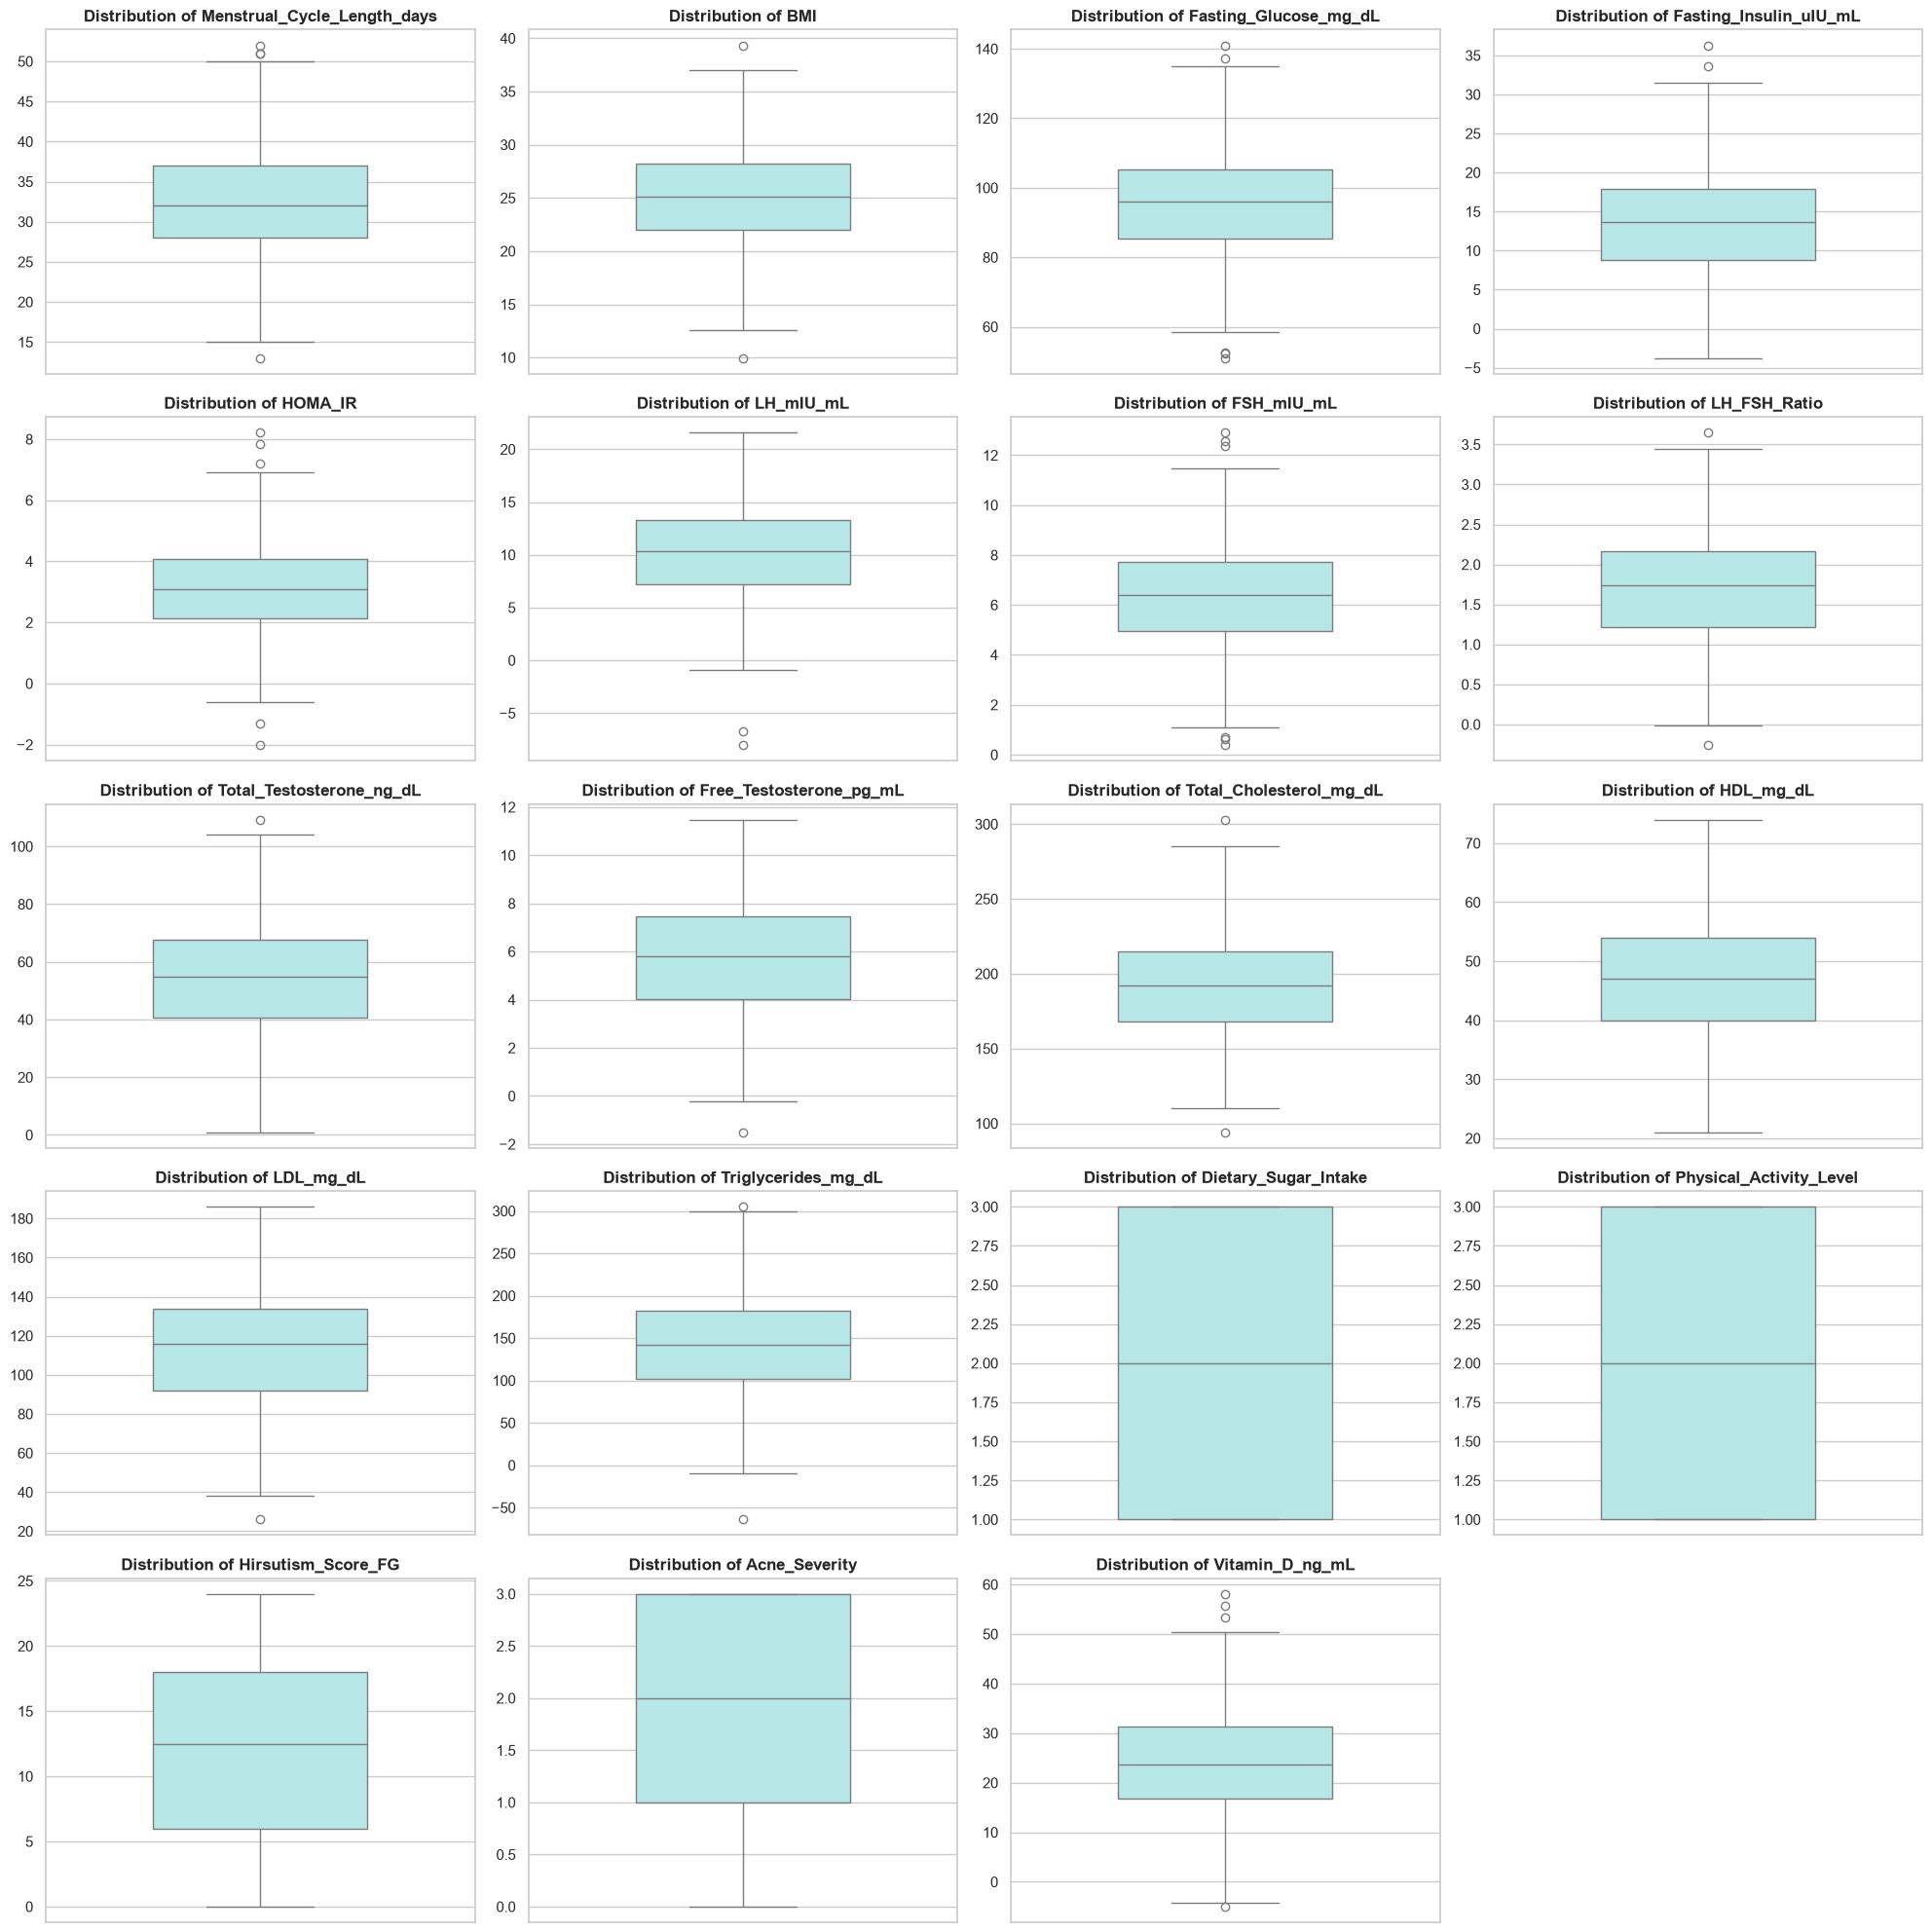

In [140]:
#Inline plotting
%matplotlib inline
sns.set_theme(style="whitegrid") #setting white grid style for box plots

#Only creating boxplots of continuous numeric features
cont_features = []
for col in df_2.select_dtypes(include=['number']).columns:
    if df_2[col].nunique() > 2: #excluding the binary features which only have 2 unique values
        cont_features.append(col)

num_features = len(cont_features)
print(num_features)

#Making 4 features display per row
features_per_row = 4
num_rows = (num_features + features_per_row - 1) // features_per_row
#Figure size configuration
fig, axes = plt.subplots(nrows=num_rows, ncols=features_per_row, figsize=(20, num_rows * 4))
axes = axes.flatten()

#Iteration through every continuous feature and creating the boxplot
for i, col in enumerate(cont_features):
    sns.boxplot(data=df_2, y=col, ax=axes[i], color="paleturquoise", width=0.5)
    axes[i].set_title(f"Distribution of {col}", fontweight='bold')
    axes[i].set_ylabel("")

#Hiding blank subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

#Adjusting spaces and display
plt.tight_layout()
plt.show()


In [141]:
#Checking if their are any missing values
na_count = df_2.isnull().sum()
print(na_count)

Menstrual_Cycle_Length_days    0
Menstrual_Irregularity         0
BMI                            0
Fasting_Glucose_mg_dL          0
Fasting_Insulin_uIU_mL         0
HOMA_IR                        0
LH_mIU_mL                      0
FSH_mIU_mL                     0
LH_FSH_Ratio                   0
Total_Testosterone_ng_dL       0
Free_Testosterone_pg_mL        0
Total_Cholesterol_mg_dL        0
HDL_mg_dL                      0
LDL_mg_dL                      0
Triglycerides_mg_dL            0
Dietary_Sugar_Intake           0
Physical_Activity_Level        0
PCOS_Diagnosis                 0
Hirsutism_Score_FG             0
Acne_Severity                  0
Alopecia                       0
Skin_Darkening_Acanthosis      0
Vitamin_D_ng_mL                0
dtype: int64


### Assessing Negative values of Continuous Numeric Features

In [142]:
#It is impossible for these levels to be below zero

#Count of negative values in column Fasting Insulin 
fasting_insulin_neg_count = (df_2['Fasting_Insulin_uIU_mL'] < 0).sum()
print(f"Number of negative values in Fasting Insulin: {fasting_insulin_neg_count}")

#Count of negative values in column HOMA
homa_neg_count = (df_2['HOMA_IR'] < 0).sum()
print(f"Number of negative values in HOMA: {homa_neg_count}")

#Count of negative values in column LH
lh_neg_count = (df_2['LH_mIU_mL'] < 0).sum()
print(f"Number of negative values in LH: {lh_neg_count}")

#Count of negative values in column LH to FSH Ratio
lh_fsh_ratio_neg_count = (df_2['LH_FSH_Ratio'] < 0).sum()
print(f"Number of negative values in LH to FSH Ratio: {lh_fsh_ratio_neg_count}")

#Count of negative values in column Free Testosterone 
free_tes_neg_count = (df_2['Free_Testosterone_pg_mL'] < 0).sum()
print(f"Number of negative values in ree Testosterone: {free_tes_neg_count}")

#Count of negative values in column Triglycerides 
triglycerides_neg_count = (df_2['Triglycerides_mg_dL'] < 0).sum()
print(f"Number of negative values in Triglycerides: {triglycerides_neg_count}")

#Count of negative values in column Vitamin D
vitamin_d_neg_count = (df_2['Vitamin_D_ng_mL'] < 0).sum()
print(f"Number of negative values in Vitamin D: {vitamin_d_neg_count}")


Number of negative values in Fasting Insulin: 12
Number of negative values in HOMA: 7
Number of negative values in LH: 5
Number of negative values in LH to FSH Ratio: 2
Number of negative values in ree Testosterone: 5
Number of negative values in Triglycerides: 2
Number of negative values in Vitamin D: 4


### Median Imputation of Negative Values within Features: Fasting_Insulin_uIU_mL, HOMA_IR, LH_mIU_mL, Free_Testosterone_pg_mL, Triglycerides_mg_dL

In [143]:
#Median Imputation
#First change negative values to NaN 

cols = [
    'Fasting_Insulin_uIU_mL',
    'HOMA_IR',
    'LH_mIU_mL',
    'Free_Testosterone_pg_mL',
    'Triglycerides_mg_dL',
    'Vitamin_D_ng_mL'
]

#Converting negative values to nan
df_2[cols] = df_2[cols].mask(df_2[cols] < 0, np.nan)

#Checking to see if negative values were removed
print("Remaining negative values: ")
print((df_2[cols] < 0).sum())


Remaining negative values: 
Fasting_Insulin_uIU_mL     0
HOMA_IR                    0
LH_mIU_mL                  0
Free_Testosterone_pg_mL    0
Triglycerides_mg_dL        0
Vitamin_D_ng_mL            0
dtype: int64


In [ ]:
#Converting NaN values to median values
for col in ['Fasting_Insulin_uIU_mL', 'HOMA_IR', 'LH_mIU_mL',
            'Free_Testosterone_pg_mL', 'Triglycerides_mg_dL', 'Vitamin_D_ng_mL']:
    col_median = df_2[col].median()
    df_2[col] = df_2[col].fillna(col_median)

#Checking that the dataset still contains 468 rows
print(f"Data shape: {df_2.shape}")

Data shape: (468, 23)


In [145]:
#Recalculating LH to FSH Ratio column and HOMA IR column
#For mathematical integrity

#LH/FSH Ratio Formula
df_2['LH_FSH_Ratio'] = df_2['LH_mIU_mL'] / df_2['FSH_mIU_mL']

#HOMA IR Formula
df_2['HOMA_IR'] = (df_2['Fasting_Insulin_uIU_mL'] * df_2['Fasting_Glucose_mg_dL']) / 405

In [146]:
df_2.head()

,Menstrual_Cycle_Length_days,Menstrual_Irregularity,BMI,Fasting_Glucose_mg_dL,Fasting_Insulin_uIU_mL,HOMA_IR,LH_mIU_mL,FSH_mIU_mL,LH_FSH_Ratio,Total_Testosterone_ng_dL,Free_Testosterone_pg_mL,Total_Cholesterol_mg_dL,HDL_mg_dL,LDL_mg_dL,Triglycerides_mg_dL,Dietary_Sugar_Intake,Physical_Activity_Level,PCOS_Diagnosis,Hirsutism_Score_FG,Acne_Severity,Alopecia,Skin_Darkening_Acanthosis,Vitamin_D_ng_mL
0,33,0,25.82,96.7,17.87,4.266738,7.40,4.77,1.551363,52.1,8.42,142,27,97,299.0,2,2,1,17,2,0,0,46.3
1,26,1,31.36,115.0,18.86,5.355309,16.14,5.49,2.939891,79.1,8.25,186,58,86,131.0,1,2,0,20,3,0,1,24.8
2,38,0,22.90,75.0,15.61,2.890741,10.52,8.10,1.298765,59.4,3.87,138,30,162,103.0,1,1,0,11,2,0,0,22.2
3,31,1,23.68,106.2,14.21,3.726178,13.85,9.88,1.401822,83.5,2.30,94,53,122,179.0,3,1,0,9,0,1,0,18.9
4,32,0,29.05,91.9,15.21,3.451356,14.03,8.42,1.666271,44.8,3.72,208,70,55,137.0,3,2,0,24,1,0,0,46.4


In [147]:
#Forcing pandas to show all the columns and rows
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

df_2.describe()

,Menstrual_Cycle_Length_days,Menstrual_Irregularity,BMI,Fasting_Glucose_mg_dL,Fasting_Insulin_uIU_mL,HOMA_IR,LH_mIU_mL,FSH_mIU_mL,LH_FSH_Ratio,Total_Testosterone_ng_dL,Free_Testosterone_pg_mL,Total_Cholesterol_mg_dL,HDL_mg_dL,LDL_mg_dL,Triglycerides_mg_dL,Dietary_Sugar_Intake,Physical_Activity_Level,PCOS_Diagnosis,Hirsutism_Score_FG,Acne_Severity,Alopecia,Skin_Darkening_Acanthosis,Vitamin_D_ng_mL
count,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000
mean,32.061966,0.420940,25.060919,96.229274,13.981068,3.328882,10.332906,6.329487,1.971220,54.905983,5.788590,191.173077,47.429487,113.155983,143.814103,1.970085,2.010684,0.444444,12.181624,1.572650,0.220085,0.254274,24.261752
std,6.826890,0.494238,4.631783,14.870618,6.505324,1.644111,4.307014,2.079049,1.845632,19.540965,2.345415,34.267276,9.809172,29.744940,56.729888,0.811562,0.829007,0.497436,7.292536,1.097525,0.414747,0.435918,10.121257
min,13.000000,0.000000,9.950000,51.000000,0.000000,0.000000,0.130000,0.380000,0.016291,0.900000,0.050000,94.000000,21.000000,26.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.600000
25%,28.000000,0.000000,21.970000,85.475000,9.317500,2.150465,7.437500,4.952500,1.141172,40.675000,4.117500,168.000000,40.000000,92.000000,102.750000,1.000000,1.000000,0.000000,6.000000,1.000000,0.000000,0.000000,17.175000
50%,32.000000,0.000000,25.100000,95.900000,13.850000,3.228949,10.520000,6.390000,1.672507,54.950000,5.860000,192.000000,47.000000,116.000000,143.000000,2.000000,2.000000,0.000000,12.500000,2.000000,0.000000,0.000000,23.800000
75%,37.000000,1.000000,28.252500,105.400000,17.960000,4.344692,13.302500,7.717500,2.260424,67.800000,7.452500,215.000000,54.000000,134.000000,182.250000,3.000000,3.000000,1.000000,18.000000,3.000000,0.000000,1.000000,31.275000
max,52.000000,1.000000,39.340000,141.000000,36.290000,8.915691,21.590000,12.910000,23.098361,109.300000,11.480000,303.000000,74.000000,186.000000,305.000000,3.000000,3.000000,1.000000,24.000000,3.000000,1.000000,1.000000,58.100000


In [148]:
#Count of zero values in column Fasting_Insulin_uIU_mL
fast_insu_zero_count = (df_2['Fasting_Insulin_uIU_mL'] == 0).sum()
print(f"Number of zero values in Fasting_Insulin_uIU_mL: {fast_insu_zero_count}")

#Count of zero values in column HOMA_IR
homa_zero_count = (df_2['HOMA_IR'] == 0).sum()
print(f"Number of zero values in HOMA_IR: {homa_zero_count}")

#Count of zero values in Triglycerides_mg_dL
triglycerides_zero_count = (df_2['Triglycerides_mg_dL'] == 0).sum()
print(f"Number of zero values in Triglycerides: {triglycerides_zero_count}")

#Count of zero values in Vitamin_D_ng_mL
vit_d_zero_count = (df_2['Vitamin_D_ng_mL'] == 0).sum()
print(f"Number of zero values in Vitamin D: {vit_d_zero_count}")

Number of zero values in Fasting_Insulin_uIU_mL: 1
Number of zero values in HOMA_IR: 1
Number of zero values in Triglycerides: 1
Number of zero values in Vitamin D: 0


In [149]:
#Replacing zero values with NaN
for col in ['Fasting_Insulin_uIU_mL', 'Triglycerides_mg_dL']:
    df_2[col] = df_2[col].replace(0.0, np.nan)
    col_median = df_2[col].median()
    df_2[col] = df_2[col].fillna(col_median)
    
#Recalculating HOMA IR again
#HOMA IR Formula
df_2['HOMA_IR'] = (df_2['Fasting_Insulin_uIU_mL'] * df_2['Fasting_Glucose_mg_dL']) / 405

#Checking to see if zero values were removed
print("Remaining zero values: ")
print((df_2[['Fasting_Insulin_uIU_mL', 'Triglycerides_mg_dL', 'HOMA_IR']] == 0).sum())


Remaining zero values: 
Fasting_Insulin_uIU_mL    0
Triglycerides_mg_dL       0
HOMA_IR                   0
dtype: int64


In [150]:
#Forcing pandas to show all the columns and rows
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

df_2.describe()

,Menstrual_Cycle_Length_days,Menstrual_Irregularity,BMI,Fasting_Glucose_mg_dL,Fasting_Insulin_uIU_mL,HOMA_IR,LH_mIU_mL,FSH_mIU_mL,LH_FSH_Ratio,Total_Testosterone_ng_dL,Free_Testosterone_pg_mL,Total_Cholesterol_mg_dL,HDL_mg_dL,LDL_mg_dL,Triglycerides_mg_dL,Dietary_Sugar_Intake,Physical_Activity_Level,PCOS_Diagnosis,Hirsutism_Score_FG,Acne_Severity,Alopecia,Skin_Darkening_Acanthosis,Vitamin_D_ng_mL
count,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000
mean,32.061966,0.420940,25.060919,96.229274,14.010662,3.336043,10.332906,6.329487,1.971220,54.905983,5.788590,191.173077,47.429487,113.155983,144.119658,1.970085,2.010684,0.444444,12.181624,1.572650,0.220085,0.254274,24.261752
std,6.826890,0.494238,4.631783,14.870618,6.473008,1.636863,4.307014,2.079049,1.845632,19.540965,2.345415,34.267276,9.809172,29.744940,56.337377,0.811562,0.829007,0.497436,7.292536,1.097525,0.414747,0.435918,10.121257
min,13.000000,0.000000,9.950000,51.000000,0.010000,0.002291,0.130000,0.380000,0.016291,0.900000,0.050000,94.000000,21.000000,26.000000,5.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.600000
25%,28.000000,0.000000,21.970000,85.475000,9.360000,2.158486,7.437500,4.952500,1.141172,40.675000,4.117500,168.000000,40.000000,92.000000,103.000000,1.000000,1.000000,0.000000,6.000000,1.000000,0.000000,0.000000,17.175000
50%,32.000000,0.000000,25.100000,95.900000,13.850000,3.237133,10.520000,6.390000,1.672507,54.950000,5.860000,192.000000,47.000000,116.000000,143.000000,2.000000,2.000000,0.000000,12.500000,2.000000,0.000000,0.000000,23.800000
75%,37.000000,1.000000,28.252500,105.400000,17.960000,4.344692,13.302500,7.717500,2.260424,67.800000,7.452500,215.000000,54.000000,134.000000,182.250000,3.000000,3.000000,1.000000,18.000000,3.000000,0.000000,1.000000,31.275000
max,52.000000,1.000000,39.340000,141.000000,36.290000,8.915691,21.590000,12.910000,23.098361,109.300000,11.480000,303.000000,74.000000,186.000000,305.000000,3.000000,3.000000,1.000000,24.000000,3.000000,1.000000,1.000000,58.100000


### Identifying Outliers

In [ ]:
#Columns to include
cont_cols = [ 'Fasting_Glucose_mg_dL', 'Fasting_Insulin_uIU_mL',
              'HOMA_IR', 'LH_mIU_mL', 'FSH_mIU_mL', 'LH_FSH_Ratio',
                'Total_Testosterone_ng_dL', 'Free_Testosterone_pg_mL', 
                'Total_Cholesterol_mg_dL', 'HDL_mg_dL', 'LDL_mg_dL', 
                'Triglycerides_mg_dL', 'Hirsutism_Score_FG', 'Vitamin_D_ng_mL']

outlier_data = []

#Iterative for loop function to calculate the outliers for the features
for col in cont_cols: 
    
    #Calculating the quartiles and IQR
    Q1 = df_2[col].quantile(0.25)
    Q3 = df_2[col].quantile(0.75)
    IQR = Q3 - Q1

    #Calculating the lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    #Finding the rows that breach the bounds
    outliers = df_2[(df_2[col] < lower_bound) | (df_2[col] > upper_bound)]
    outlier_count = len(outliers)
    percentage = (outlier_count / len(df_2)) * 100

    #Appending all the necessary outlier data
    outlier_data.append({
        'Feature': col,
        'Number of Outliers': outlier_count,
        'Percentage of Outliers': percentage,
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2)
    })

#Compiling the outlier data for each feature into a dataframe
df_outliers = pd.DataFrame(outlier_data)

#Sorting the dataframe by order of the number of outliers
df_outliers = df_outliers.sort_values(by='Number of Outliers', ascending=False)

#Viewing the dataframe
df_outliers

,Feature,Number of Outliers,Percentage of Outliers,Lower Bound,Upper Bound
5,LH_FSH_Ratio,29,6.196581,-0.54,3.94
4,FSH_mIU_mL,6,1.282051,0.80,11.87
2,HOMA_IR,5,1.068376,-1.12,7.62
0,Fasting_Glucose_mg_dL,5,1.068376,55.59,135.29
1,Fasting_Insulin_uIU_mL,3,0.641026,-3.54,30.86
13,Vitamin_D_ng_mL,3,0.641026,-3.97,52.42
8,Total_Cholesterol_mg_dL,2,0.427350,97.50,285.50
11,Triglycerides_mg_dL,1,0.213675,-15.88,301.12
10,LDL_mg_dL,1,0.213675,29.00,197.00
6,Total_Testosterone_ng_dL,1,0.213675,-0.01,108.49


### Creating Histograms to assess the distributions of features

19


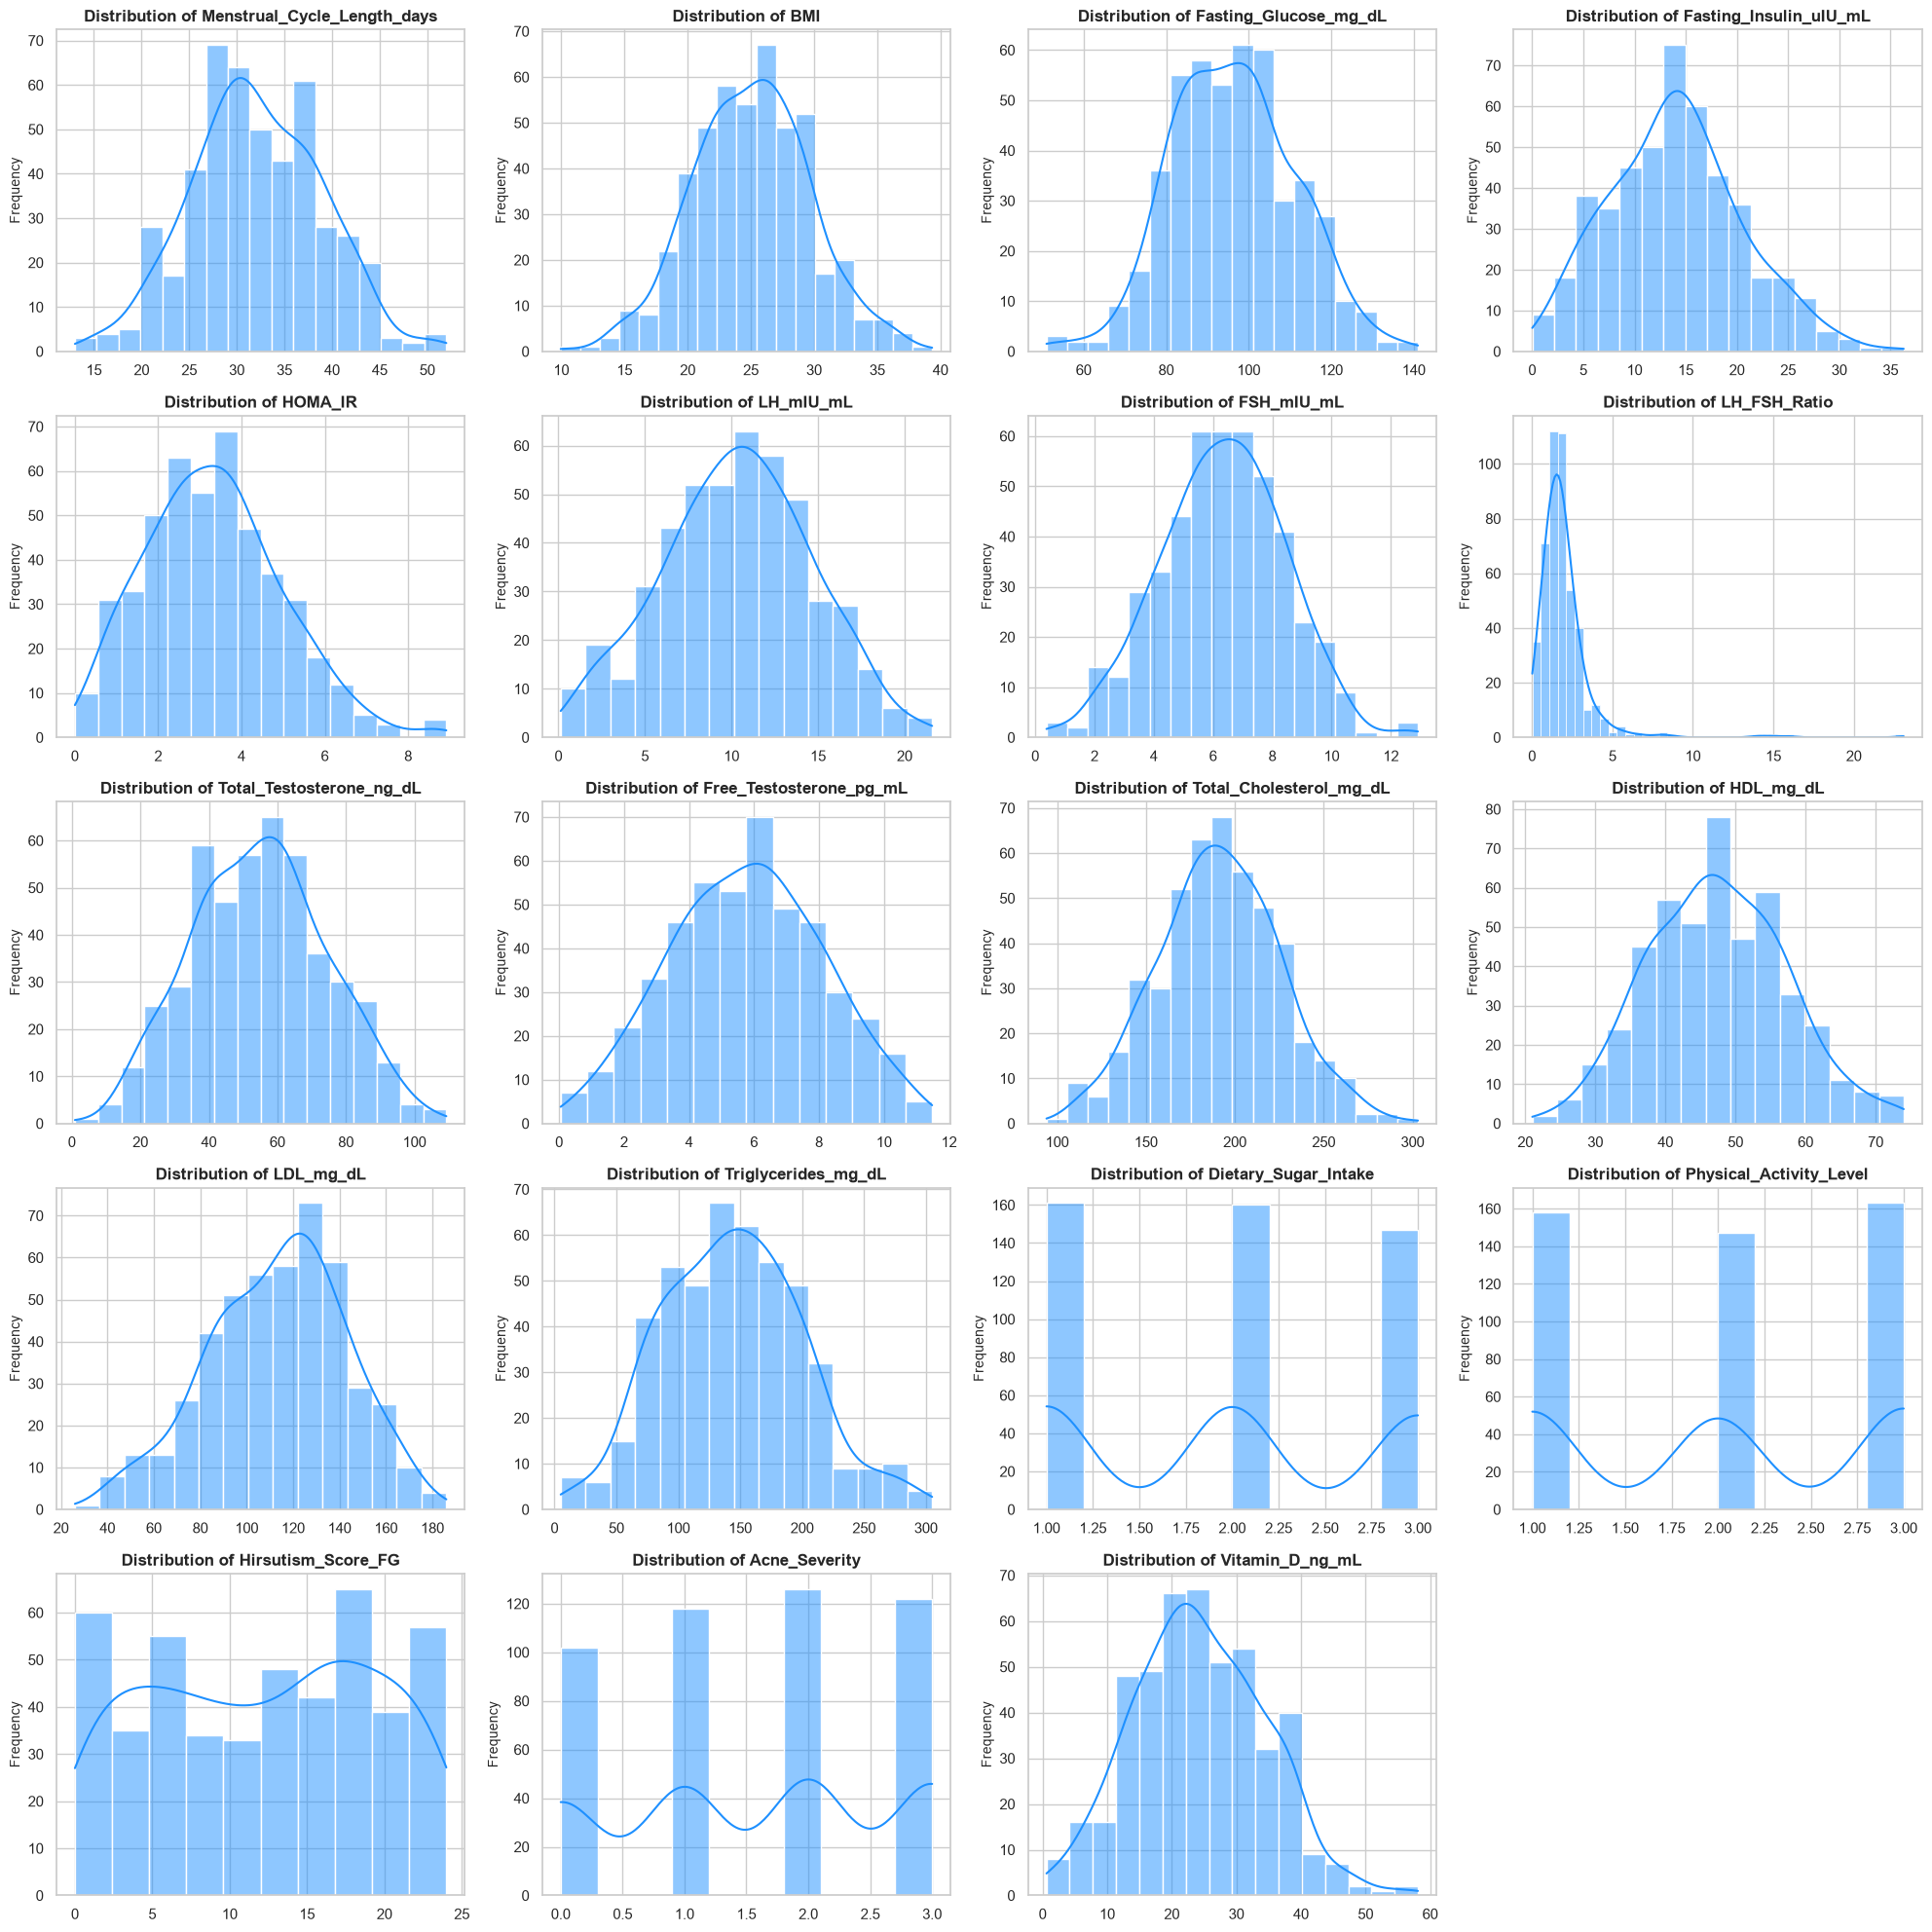

In [152]:
#Inline plotting
%matplotlib inline
sns.set_theme(style="whitegrid") #setting white grid style for box plots

#Only creating boxplots of continuous numeric features
cont_features = []
for col in df_2.select_dtypes(include=['number']).columns:
    if df_2[col].nunique() > 2: #excluding the binary features which only have 2 unique values
        cont_features.append(col)

num_features = len(cont_features)
print(num_features)

#Making 4 features display per row
features_per_row = 4
num_rows = (num_features + features_per_row - 1) // features_per_row
#Figure size configuration
fig, axes = plt.subplots(nrows=num_rows, ncols=features_per_row, figsize=(20, num_rows * 4))
axes = axes.flatten()

#Iteration through every continuous feature and creating the histogram
for i, col in enumerate(cont_features):
    sns.histplot(data=df_2, x=col, ax=axes[i], kde=True, color="dodgerblue", bins='auto')
    axes[i].set_title(f"Distribution of {col}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("") #Getting rid of redundant x axis label
    axes[i].set_ylabel("Frequency", fontsize=10)

    #Hiding blank subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [153]:
#Saving the cleaned dataset to a new file
df_2.to_excel('clean_pcos_data.xlsx', index=False)

### Creating a sythentic target variable: Nutrient vector
### Creating the python logic for the features to decide the level of nutrients needed

In [ ]:
#Nutrient reccomender python logic

def nutrient_vector(patient_record):

    # Set a baseline daily reccomended intake of nutrients
    magnesium = 320.0 #milligrams
    fibre = 25.0 #grams
    PUFA = 12.0 #grams

    #Fiber reccomendation logic
    #High HOMA IR or high Fasting Glucose level can indicate insulin resistance
    #From high severity to mild using if and elif
    if patient_record['HOMA_IR'] > 5 or patient_record['Fasting_Glucose_mg_dL'] > 126:
        fibre += 10

    elif 3 <= patient_record['HOMA_IR'] <= 4.9 or 112.6 <= patient_record['Fasting_Glucose_mg_dL'] <= 125:
        fibre += 7.5 

    elif 2 <= patient_record['HOMA_IR'] <= 2.9 or 100 <= patient_record['Fasting_Glucose_mg_dL'] <= 112.5:
        fibre += 5
        
    elif patient_record['HOMA_IR'] > 1.9 or patient_record['Fasting_Glucose_mg_dL'] > 99:
        fibre += 2.5

    #Polyunsatured fats (PUFAs) reccommendation logic (as a replacement for Omega 3)
    #High triglycerides and the presence of severe acne can indicate high lipids and inflammation
    #Omega 3 can lower lipid levels and combat skin inflammation
    #From high severity to mild using if and elif
    if patient_record['Triglycerides_mg_dL'] > 249 or patient_record['Acne_Severity'] == 3:
        PUFA += 8
          
    elif 200 <= patient_record['Triglycerides_mg_dL'] <= 249 or patient_record['Acne_Severity'] == 2:
        PUFA += 4

    elif 150 <= patient_record['Triglycerides_mg_dL'] <= 199 or patient_record['Acne_Severity'] == 1:
        PUFA += 2
        

    #Magnesium reccomendation logic
    #Magnesium can support insulin resistance and hormonal imbalance
    #From high severity to mild using if and elif
    if patient_record['HOMA_IR'] > 5:
        if patient_record['PCOS_Diagnosis'] == 1:
            magnesium += 80
        else:
            magnesium += 70

    elif 3 <= patient_record['HOMA_IR'] <= 4.9:
        if patient_record['PCOS_Diagnosis'] == 1:
            magnesium += 50
        else:
            magnesium += 40
        
    elif 2 <= patient_record['HOMA_IR'] <= 2.9:
        if patient_record['PCOS_Diagnosis'] == 1:
            magnesium += 35
        else:
            magnesium += 25

    #Round the nutrient figures
    return [round(fibre, 1), round(PUFA, 1), round(magnesium, 1)]

#Testing the reccomender logic on first patient
patient_1 = df_2.iloc[0]
target_vector = nutrient_vector(patient_1)

print(f"Target Nutrient Vector for patient 1: {target_vector}")



Target Nutrient Vector for patient 1: [32.5, 20.0, 370.0]


In [155]:
#Running the nutrient vector logic across all rows in the PCOS dataset
df_2['Target_Nutrient_Vector'] = df_2.apply(nutrient_vector, axis=1)

print("Dataset with integrated target nutrient vector:")
print(df_2[['Fasting_Glucose_mg_dL', 'HOMA_IR', 'Triglycerides_mg_dL', 'Acne_Severity', 'LH_FSH_Ratio', 'Target_Nutrient_Vector']].head())

Dataset with integrated target nutrient vector:
   Fasting_Glucose_mg_dL   HOMA_IR  Triglycerides_mg_dL  Acne_Severity  \
0                   96.7  4.266738                299.0              2   
1                  115.0  5.355309                131.0              3   
2                   75.0  2.890741                103.0              2   
3                  106.2  3.726178                179.0              0   
4                   91.9  3.451356                137.0              1   

   LH_FSH_Ratio Target_Nutrient_Vector  
0      1.551363    [32.5, 20.0, 370.0]  
1      2.939891    [35.0, 20.0, 390.0]  
2      1.298765    [30.0, 16.0, 345.0]  
3      1.401822    [32.5, 14.0, 360.0]  
4      1.666271    [32.5, 14.0, 360.0]  


In [156]:
df_2.head()

,Menstrual_Cycle_Length_days,Menstrual_Irregularity,BMI,Fasting_Glucose_mg_dL,Fasting_Insulin_uIU_mL,HOMA_IR,LH_mIU_mL,FSH_mIU_mL,LH_FSH_Ratio,Total_Testosterone_ng_dL,Free_Testosterone_pg_mL,Total_Cholesterol_mg_dL,HDL_mg_dL,LDL_mg_dL,Triglycerides_mg_dL,Dietary_Sugar_Intake,Physical_Activity_Level,PCOS_Diagnosis,Hirsutism_Score_FG,Acne_Severity,Alopecia,Skin_Darkening_Acanthosis,Vitamin_D_ng_mL,Target_Nutrient_Vector
0,33,0,25.82,96.7,17.87,4.266738,7.40,4.77,1.551363,52.1,8.42,142,27,97,299.0,2,2,1,17,2,0,0,46.3,"[32.5, 20.0, 370.0]"
1,26,1,31.36,115.0,18.86,5.355309,16.14,5.49,2.939891,79.1,8.25,186,58,86,131.0,1,2,0,20,3,0,1,24.8,"[35.0, 20.0, 390.0]"
2,38,0,22.90,75.0,15.61,2.890741,10.52,8.10,1.298765,59.4,3.87,138,30,162,103.0,1,1,0,11,2,0,0,22.2,"[30.0, 16.0, 345.0]"
3,31,1,23.68,106.2,14.21,3.726178,13.85,9.88,1.401822,83.5,2.30,94,53,122,179.0,3,1,0,9,0,1,0,18.9,"[32.5, 14.0, 360.0]"
4,32,0,29.05,91.9,15.21,3.451356,14.03,8.42,1.666271,44.8,3.72,208,70,55,137.0,3,2,0,24,1,0,0,46.4,"[32.5, 14.0, 360.0]"


In [157]:
##Saving the dataset with the target feature to a new file
#df_2.to_excel('pcos_data_with_nutrition.xlsx', index=False)

### Creating a multi output regression model to predict the target nutrient vector 

In [158]:
#Creating the nutrient vector for machine learning prediction
nutrient_list = []
for index, row in df_2.iterrows():
    vector = nutrient_vector(row)
    nutrient_list.append(vector)

X=df_2.drop(columns=['Target_Nutrient_Vector'])
Y=pd.DataFrame(nutrient_list, columns=['Target_Fibre', 'Target_PUFA', 'Target_Magnesium'])

#Splitting the data into training and test sets (80/20 split)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

#Seperate continuous features from ordinal/binary features for scaling
continuous_features = ['Menstrual_Cycle_Length_days', 'BMI', 'Fasting_Glucose_mg_dL', 'Fasting_Insulin_uIU_mL', 'HOMA_IR', 'LH_mIU_mL', 'FSH_mIU_mL', 'LH_FSH_Ratio', 'Total_Testosterone_ng_dL', 'Free_Testosterone_pg_mL', 'Total_Cholesterol_mg_dL', 'HDL_mg_dL', 'LDL_mg_dL', 'Triglycerides_mg_dL']
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

#Applying the scaler to the continuous columns only
X_train_scaled[continuous_features] = scaler.fit_transform(X_train[continuous_features])
X_test_scaled[continuous_features] = scaler.transform(X_test[continuous_features])


### Random Forest Model

In [159]:
#Initialising a random forest model
rf_1 = RandomForestRegressor(n_estimators=100, random_state=64, max_depth=8)

#Predicting multiple continuous outputs
rf_nutrient_predictor = MultiOutputRegressor(rf_1)

#Training the model on the training subset
rf_nutrient_predictor.fit(X_train_scaled, Y_train)

#Making prediction on the test subset
Y_pred = rf_nutrient_predictor.predict(X_test_scaled)

#Creatinga dataframe for comparison of results
df_predictions = pd.DataFrame(Y_pred, columns=['Pred_Fibre', 'Pred_PUFA', 'Pred_Magnesium'], index=Y_test.index)

#Viewing the predictions
print(df_predictions.head())

     Pred_Fibre  Pred_PUFA  Pred_Magnesium
55         35.0      12.00           390.0
63         25.0      12.00           320.0
33         25.0      12.00           320.0
297        30.0      14.00           345.0
72         30.0      16.08           355.0


In [160]:
#Calculating the performance of the random forest predictions using metrics

for i, col in enumerate(Y.columns):
    mae = mean_absolute_error(Y_test.iloc[:, i], Y_pred[:, i])
    r2 = r2_score(Y_test.iloc[:, i], Y_pred[:, i])
    print(f" {col:<18} MAE: {mae:.2f} | R^2 Score: {r2:.2f}")

 Target_Fibre       MAE: 0.18 | R^2 Score: 0.97
 Target_PUFA        MAE: 0.04 | R^2 Score: 0.99
 Target_Magnesium   MAE: 0.20 | R^2 Score: 1.00


### Connecting target nutrition vector levels to suitable foods
### Cosine Similarity

In [161]:
#Target nutrients matching to nutrients names in the USDA Nutrition/Food datasets

#Loading the nutrition datasets
df_food = pd.read_csv('food.csv')
df_food_nutrient = pd.read_csv('food_nutrient.csv')
df_nutrient = pd.read_csv('nutrient.csv')

#Seperating the target nutrients using the USDA nutrient ids
usda_ids = [291, 646, 304]
df_selected_nutrients = df_nutrient[df_nutrient['nutrient_nbr'].isin(usda_ids)]

#Relational Merge Pipeline
#Linking the filtered nutrients to the bridge table
merge_part1 = pd.merge(df_food_nutrient, df_selected_nutrients, left_on='nutrient_id', right_on='id', how='inner')

#Linking the result to food name table
df_joined = pd.merge(merge_part1, df_food, on='fdc_id', how='inner')

#Converting the table from a vertical format to horizontal format
#Each row represents one unique food
food_matrix = df_joined.pivot_table(
    index='description',
    columns='name',
    values='amount',
    aggfunc='mean'
).fillna(0)

#Vector for the target nutrients 
target_nutrients = [
    'Fiber, total dietary', 
    'Fatty acids, total polyunsaturated',
    'Magnesium, Mg' 
]

filtered_food_matrix = food_matrix[target_nutrients]

#Cosine similarity reccomender function
def recommend_food(patient_vector, food_db, top_n=10):

    #Converting patient vectors to a 2D row array
    vector_array_2d = np.array(patient_vector).reshape(1, -1)

    #Calculating the Cosine Similarity across all matrix rows simultaneously 
    similar_scores = cosine_similarity(vector_array_2d, food_db)[0]

    #Compiling the results into a readable output table
    results_df = food_db.copy()
    results_df['Match Score (%)'] = np.round(similar_scores * 100, 2)

    #Sorting from highest geometric match to lowest
    return results_df.sort_values(by='Match Score (%)', ascending=False).head(top_n)

patient_vector_test = [35.0, 20.0, 400.0]

top_reccomendations = recommend_food(patient_vector_test, filtered_food_matrix, top_n=5)
print("Top matching food reccomended:")
print(top_reccomendations)


Top matching food reccomended:
name                                                Fiber, total dietary  \
description                                                                
Edamame, frozen, prepared                                         6.2326   
Restaurant, Latino, pupusas con frijoles (pupus...                5.8000   
Bread, white, commercially prepared                               2.3000   
Sauce, pasta, spaghetti/marinara, ready-to-serve                  1.8000   
Restaurant, Latino, tamale, pork                                  2.4000   

name                                                Fatty acids, total polyunsaturated  \
description                                                                              
Edamame, frozen, prepared                                                       4.0726   
Restaurant, Latino, pupusas con frijoles (pupus...                              2.8800   
Bread, white, commercially prepared                                         

C:\Users\Lily Jayne Baxendale\AppData\Local\Temp\ipykernel_33308\3457383676.py:5: DtypeWarning: Columns (0: footnote) have mixed types. Specify dtype option on import or set low_memory=False.
  df_food_nutrient = pd.read_csv('food_nutrient.csv')


### Classifying the phase of a patient's cycle based on their LH and FSH Levels using Euclidean Distance

In [162]:
#Creating a function to classify the phase
def classify_phase(row):
    #Classifying the cycle phase based on typical midpoints derived from clinical literature
    lh = row['LH_mIU_mL']
    fsh = row['FSH_mIU_mL']

    #Defining the clinical midpoint centers for LH and FSH levels for each phase
    phase_centers = {
        'Follicular Phase': [np.mean([1.9, 14.6]), np.mean([3.9, 8.8])],
        'Ovulatory Phase': [np.mean([6.5, 118.0]), np.mean([4.5, 22.5])],
        'Luteal Phase': [np.mean([0.7, 12.9]), np.mean([1.8, 5.1])]
    }

    #Calculating the straight-line distance from the patient's data to each center of the phase
    distances = {}

    #For loop to calculate the Euclidean distance
    for phase_name, center in phase_centers.items():
        #Standard Euclidean distance formula: sqrt((x1-x2)^2 + (y1-y2)^2)
        dist = np.sqrt((lh - center[0])**2 + (fsh - center[1])**2)
        distances[phase_name] = dist

    #Returning the phase name with the smallest geometric distance
    best_phase_match = min(distances, key=distances.get)
    return best_phase_match

#Creating the phase classification column in the dataset
df_2['Cycle_Phase_Estimate'] = df_2.apply(classify_phase, axis=1)

#Inspecting the first few rows 
print("Cycle Phase Estimates based on LH and FSH levels:")
print(df_2[['LH_mIU_mL', 'FSH_mIU_mL', 'Cycle_Phase_Estimate']].head(10))

Cycle Phase Estimates based on LH and FSH levels:
   LH_mIU_mL  FSH_mIU_mL Cycle_Phase_Estimate
0       7.40        4.77         Luteal Phase
1      16.14        5.49     Follicular Phase
2      10.52        8.10     Follicular Phase
3      13.85        9.88     Follicular Phase
4      14.03        8.42     Follicular Phase
5      16.65        5.19     Follicular Phase
6      10.68        2.45         Luteal Phase
7       7.63        5.82     Follicular Phase
8       9.09        4.96     Follicular Phase
9      14.09        8.63     Follicular Phase


In [163]:
pcos_count = (df_2['PCOS_Diagnosis'] == 1).sum()
print(f"Number of patients with PCOS: {pcos_count}")

Number of patients with PCOS: 208


In [164]:
patient_vector_test2 = [30.0, 24.0, 370.0]

top_reccomendations = recommend_food(patient_vector_test2, filtered_food_matrix, top_n=5)
print("Top matching food reccomended:")
print(top_reccomendations)

Top matching food reccomended:
name                                 Fiber, total dietary  \
description                                                 
Bread, white, commercially prepared               2.30000   
Edamame, frozen, prepared                         6.23260   
Restaurant, Latino, tamale, pork                  2.40000   
Flaxseed, ground                                 23.13000   
ground flaxseed meal                             23.13125   

name                                 Fatty acids, total polyunsaturated  \
description                                                               
Bread, white, commercially prepared                             1.87000   
Edamame, frozen, prepared                                       4.07260   
Restaurant, Latino, tamale, pork                                2.03000   
Flaxseed, ground                                               24.73000   
ground flaxseed meal                                           24.73125   

name           

### Evaluating the Nutrition Vector Target Variable
### Sensitivity and Boundary Test 1: Creating Sythentic Patient Records to test the nutrient vector logic

In [165]:
#Test patients

#Patient 1: Perfect lips but extreme insulin resistance
patient_1 = {
    'HOMA_IR': 5.5, #Severe tier indicating insuling resistance
    'Fasting_Glucose_mg_dL': 130, #Severe tier indicating insuling resistance
    'Triglycerides_mg_dL': 170, #Perfectly healthy lipids below 199
    'Acne_Severity': 0, #No acne present
    'PCOS_Diagnosis': 1  
}

#Patient 2: Severe acne and high triglycerides but normal glucose 
patient_2 = {
    'HOMA_IR': 1.8, #Severe tier indicating insuling resistance
    'Fasting_Glucose_mg_dL': 80, #Severe tier indicating insuling resistance
    'Triglycerides_mg_dL': 270, #Perfectly healthy lipids below 199
    'Acne_Severity': 3, #No acne present
    'PCOS_Diagnosis': 1  
}

#Patient 3: 
patient_3 = {
    'HOMA_IR': 1.8, #Severe tier indicating insuling resistance
    'Fasting_Glucose_mg_dL': 80, #Severe tier indicating insuling resistance
    'Triglycerides_mg_dL': 160, #Perfectly healthy lipids below 199
    'Acne_Severity': 0, #No acne present
    'PCOS_Diagnosis': 0  
}

#Converting the patient dictionaries into Pandas Series
#Applying the nutrient vector logic
patient_1_record = pd.Series(patient_1)
patient_2_record = pd.Series(patient_2)
patient_3_record = pd.Series(patient_3)

nutrient_vector_1 = nutrient_vector(patient_1_record)
nutrient_vector_2 = nutrient_vector(patient_2_record)
nutrient_vector_3 = nutrient_vector(patient_3_record)

print(f"Nutrient Vector for Test Patient 1: {nutrient_vector_1}")
print(f"Nutrient Vector for Test Patient 2: {nutrient_vector_2}")
print(f"Nutrient Vector for Test Patient 3: {nutrient_vector_3}")

Nutrient Vector for Test Patient 1: [35.0, 14.0, 400.0]
Nutrient Vector for Test Patient 2: [25.0, 20.0, 320.0]
Nutrient Vector for Test Patient 3: [25.0, 14.0, 320.0]


### Evaluating the Cosine Similarity Food Recommender
### Food Database Coverage Test 1: Seeing how diverse and personalised the food recommendations are 

In [166]:
#Creating a function to loop through all 468 patient records
def food_catalog_coverage(patient_df, food_db, top_n=10):
    #Calculating the percentage of unique foods used across the entire patient dataset
    #Initialising an empty set to collect only unique recommended food names and avoid duplicates
    unique_foods = set()

    #Looping through each patient record in the dataset
    for index, patient_record in patient_df.iterrows():

        #Applying the nutrient vector logic to each vector
        patient_vector = nutrient_vector(patient_record)

        #Passing the nutrient vectors into the Cosine Similarity recommender logic
        #Returning the top 10 foods recommended to each patient
        top_foods_df = recommend_food(patient_vector, food_db, top_n=top_n)

        #Extracting the food names from the recommendations
        #Adding these names to the unique foods set
        food_names = top_foods_df.index.tolist()
        unique_foods.update(food_names)

        #Calculating the percentage of unique foods recommended out of total food database
        total_unique_foods_recommended = len(unique_foods)
        total_foods = len(food_db)
        percentage_covered = (total_unique_foods_recommended / total_foods) * 100

        #Printing the metrics 
        print("Food Recommender Catalog Coverage")
        print(f"Total Unique Foods in Food Database: {total_foods}")
        print(f"Number of Unique Foods Recommended: {total_unique_foods_recommended}")
        print(f"Percentage of Unique Foods Recommended out of Total Foods: {percentage_covered:.2f}%")

        return unique_foods

unique_foods_calculation = food_catalog_coverage(df_2, filtered_food_matrix, top_n=10)



Food Recommender Catalog Coverage
Total Unique Foods in Food Database: 2254
Number of Unique Foods Recommended: 10
Percentage of Unique Foods Recommended out of Total Foods: 0.44%


### Nutrient Contribution Test
### Calculating how much recommended foods contribute to target nutrient levels

### Fixing Feature Scaling with Cosine Similarity for Food Recommendation 

In [167]:
# New Cosine Similarity Food recommendation engine

scaler = MinMaxScaler()
food_matrix_scaled = scaler.fit_transform(filtered_food_matrix)
food_scaled = pd.DataFrame(food_matrix_scaled, columns=filtered_food_matrix.columns, index=filtered_food_matrix.index)

def food_recommender_scaled(patient_vector, food_db, food_scaled_db, scalerobj, top_n=10):
    #Applying the MinMax scaling to the patient vector before running Cosine Similarity
    #Converting the patient vector to 2D
    vector_2d = np.array(patient_vector).reshape(1, -1)

    #Scaling the patient vector using the exact same food scaler rules
    #Calculating the similarity using the scaled spaces
    scaled_patient_vector = scalerobj.transform(vector_2d)
    score_similarity = cosine_similarity(scaled_patient_vector, food_scaled_db)[0]

    #Attaching the scores back to the original unscaled food database 
    results_df = food_db.copy()
    results_df['Match Score (%):'] = np.round(score_similarity * 100, 2)

    return results_df.sort_values(by='Match Score (%):', ascending=False).head(top_n)

test_patient = [35.0, 20.0, 400.0]
test_patient2 = [25.0, 12.0, 450.0]

top_reccomendations1 = food_recommender_scaled(test_patient, filtered_food_matrix, food_matrix_scaled, scaler, top_n=10)
print("Top matching food reccomended:")
print(top_reccomendations1)

top_reccomendations2 = food_recommender_scaled(test_patient2, filtered_food_matrix, food_matrix_scaled, scaler, top_n=10)
print("Top matching food reccomended:")
print(top_reccomendations2)

Top matching food reccomended:
name                                                Fiber, total dietary  \
description                                                                
Edamame, frozen, prepared                                        6.23260   
Restaurant, Latino, pupusas con frijoles (pupus...               5.80000   
Bread, white, commercially prepared                              2.30000   
Restaurant, Latino, tamale, pork                                 2.40000   
Sauce, pasta, spaghetti/marinara, ready-to-serve                 1.80000   
Bread, whole-wheat, commercially prepared                        6.00000   
Mustard, prepared, yellow                                        4.30000   
Refried beans, canned, vegetarian                                3.91000   
Flaxseed, ground                                                23.13000   
ground flaxseed meal                                            23.13125   

name                                                Fatt

c:\Users\Lily Jayne Baxendale\masters_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Lily Jayne Baxendale\masters_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [168]:
#New food catalogue coverage check with new cosine similarity food recommender

def scaled_catalog_coverage(patient_df, food_db, food_scaled_db, scalerobj, top_n=10):

    #Defining the set for unique foods recommended
    unique_foods_recommended = set()

    for index, patient_record in patient_df.iterrows():
        patient_vector = nutrient_vector(patient_record)

        #Scaled food recommendation function
        top_foods_df = food_recommender_scaled(
            patient_vector, food_db, food_scaled_db, scalerobj, top_n=top_n
        )

        unique_foods_recommended.update(top_foods_df.index.tolist())
    
    #Calculating the coverage percentage
    coverage_percentage = (len(unique_foods_recommended) / len(food_db)) * 100

    #Printing the metrics 
    print("Food Recommender Catalog Coverage")
    print(f"Total Unique Foods in Food Database: {len(food_db)}")
    print(f"Number of Unique Foods Recommended: {len(unique_foods_recommended)}")
    print(f"Percentage of Unique Foods Recommended out of Total Foods: {coverage_percentage:.2f}%")

    return unique_foods_recommended

#Running the catalog coverage function
unique_foods_2 = scaled_catalog_coverage(df_2, filtered_food_matrix, food_matrix_scaled, scaler, top_n=10)


c:\Users\Lily Jayne Baxendale\masters_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Lily Jayne Baxendale\masters_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Lily Jayne Baxendale\masters_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Lily Jayne Baxendale\masters_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Lily Jayne Baxendale\masters_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not 

Food Recommender Catalog Coverage
Total Unique Foods in Food Database: 2254
Number of Unique Foods Recommended: 34
Percentage of Unique Foods Recommended out of Total Foods: 1.51%


c:\Users\Lily Jayne Baxendale\masters_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Lily Jayne Baxendale\masters_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Lily Jayne Baxendale\masters_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Lily Jayne Baxendale\masters_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Lily Jayne Baxendale\masters_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not 

### Making Nutrition Vector Logic more Complex for more diverse recommendations 
#### Adding two more target nutrients: Zinc and Vitamin D

In [169]:
#Nutrient reccomender python logic

def nutrient_vector_2(patient_record):

    # Set a baseline daily reccomended intake of nutrients
    magnesium = 320.0 #milligrams
    fibre = 25.0 #grams
    PUFA = 12.0 #grams
    zinc = 7.0 #milligrams 25mg max
    vitamin_d = 10.0 #micrograms (1000 times smaller than a milligram) max 50ug

    #Fiber reccomendation logic
    #High HOMA IR or high Fasting Glucose level can indicate insulin resistance
    #Using a continuous proportional multiplier with 15g as a safety cap      
    if patient_record['HOMA_IR'] > 1.9 or patient_record['Fasting_Glucose_mg_dL'] > 99:
        fibre_addition = patient_record['HOMA_IR'] - 1.9
        fibre += min(15.0, fibre_addition * 1.5)

    #Omega 3 / Polyunsaturated fat reccommendation logic
    #High triglycerides and the presence of severe acne can indicate high lipids and inflammation
    #Omega 3 can lower lipid levels and combat skin inflammation
    #Using a continuous proportional multiplier with 10g as a safety cap
    if 150 <= patient_record['Triglycerides_mg_dL'] > 199 and patient_record['Acne_Severity'] == 3:
        PUFA_addition = patient_record['Triglycerides_mg_dL'] - 199
        PUFA += min(10.0, PUFA_addition * 1.8)

    if 150 <= patient_record['Triglycerides_mg_dL'] > 199 and patient_record['Acne_Severity'] == 2:
        PUFA_addition = patient_record['Triglycerides_mg_dL'] - 199
        PUFA += min(10.0, PUFA_addition * 1.5)

    if 150 <= patient_record['Triglycerides_mg_dL'] > 199 and patient_record['Acne_Severity'] == 1:
        PUFA_addition = patient_record['Triglycerides_mg_dL'] - 199
        PUFA += min(10.0, PUFA_addition * 1.3)

    #Magnesium reccomendation logic
    #Magnesium can support insulin resistance and hormonal imbalance
    #Using a continuous proportional multiplier with 80mg as a safety cap
    if patient_record['HOMA_IR'] > 1.9 and patient_record['PCOS_Diagnosis'] == 1:
        magnesium_addition = patient_record['HOMA_IR'] - 1.9
        magnesium += min(80, magnesium_addition * 10)

    if patient_record['HOMA_IR'] > 1.9 and patient_record['PCOS_Diagnosis'] == 0:
        magnesium_addition_2 = patient_record['HOMA_IR'] - 1.9
        magnesium += min(80, magnesium_addition_2 * 7.5)

    #Vitamin D recommendation logic
    #Vitamin D can support patients with hormonal imbalance, insulin resistance and hirsutism
    #Using a continuous proportional multiplier with 80mg as a safety cap
    if patient_record['BMI'] > 25 and patient_record['Vitamin_D_ng_mL'] < 10:
        vitamin_d_addition = patient_record['BMI'] - 25
        vitamin_d += min(40, vitamin_d_addition * 2.5)

    if patient_record['BMI'] > 25 and patient_record['Vitamin_D_ng_mL'] < 20:
            vitamin_d_addition = patient_record['BMI'] - 25
            vitamin_d += min(40, vitamin_d_addition * 1.5)

    #Zinc recommendation logic
    #Zinc can support PCOS patients with hirsutism, alopecia
    if patient_record['Total_Testosterone_ng_dL'] > 46:
        zinc_addition = patient_record['Total_Testosterone_ng_dL'] - 46
        zinc += min(18, zinc_addition * 1.5)

    #Round the nutrient figures
    return [round(fibre, 1), round(PUFA, 1), round(magnesium, 1), round(vitamin_d, 1), round(zinc, 1)]

#Testing the reccomender logic on first patient
patient_1 = df_2.iloc[0]
target_vector = nutrient_vector_2(patient_1)

print(f"Target Nutrient Vector for patient 1: {target_vector}")


Target Nutrient Vector for patient 1: [np.float64(28.6), 22.0, np.float64(343.7), 10.0, np.float64(16.2)]


In [170]:
#creating a copy of the dataframe
df_3 = df_2.copy(deep=True)
df_3.head()


,Menstrual_Cycle_Length_days,Menstrual_Irregularity,BMI,Fasting_Glucose_mg_dL,Fasting_Insulin_uIU_mL,HOMA_IR,LH_mIU_mL,FSH_mIU_mL,LH_FSH_Ratio,Total_Testosterone_ng_dL,Free_Testosterone_pg_mL,Total_Cholesterol_mg_dL,HDL_mg_dL,LDL_mg_dL,Triglycerides_mg_dL,Dietary_Sugar_Intake,Physical_Activity_Level,PCOS_Diagnosis,Hirsutism_Score_FG,Acne_Severity,Alopecia,Skin_Darkening_Acanthosis,Vitamin_D_ng_mL,Target_Nutrient_Vector,Cycle_Phase_Estimate
0,33,0,25.82,96.7,17.87,4.266738,7.40,4.77,1.551363,52.1,8.42,142,27,97,299.0,2,2,1,17,2,0,0,46.3,"[32.5, 20.0, 370.0]",Luteal Phase
1,26,1,31.36,115.0,18.86,5.355309,16.14,5.49,2.939891,79.1,8.25,186,58,86,131.0,1,2,0,20,3,0,1,24.8,"[35.0, 20.0, 390.0]",Follicular Phase
2,38,0,22.90,75.0,15.61,2.890741,10.52,8.10,1.298765,59.4,3.87,138,30,162,103.0,1,1,0,11,2,0,0,22.2,"[30.0, 16.0, 345.0]",Follicular Phase
3,31,1,23.68,106.2,14.21,3.726178,13.85,9.88,1.401822,83.5,2.30,94,53,122,179.0,3,1,0,9,0,1,0,18.9,"[32.5, 14.0, 360.0]",Follicular Phase
4,32,0,29.05,91.9,15.21,3.451356,14.03,8.42,1.666271,44.8,3.72,208,70,55,137.0,3,2,0,24,1,0,0,46.4,"[32.5, 14.0, 360.0]",Follicular Phase


In [171]:
#Running the nutrient vector logic across all rows in the PCOS dataset
df_3['Target_Nutrient_Vector'] = df_3.apply(nutrient_vector_2, axis=1)

print("Dataset with integrated target nutrient vector:")
print(df_3[['Fasting_Glucose_mg_dL', 'HOMA_IR', 'Triglycerides_mg_dL', 'Acne_Severity', 'Target_Nutrient_Vector']].head())

Dataset with integrated target nutrient vector:
   Fasting_Glucose_mg_dL   HOMA_IR  Triglycerides_mg_dL  Acne_Severity  \
0                   96.7  4.266738                299.0              2   
1                  115.0  5.355309                131.0              3   
2                   75.0  2.890741                103.0              2   
3                  106.2  3.726178                179.0              0   
4                   91.9  3.451356                137.0              1   

            Target_Nutrient_Vector  
0  [28.6, 22.0, 343.7, 10.0, 16.2]  
1  [30.2, 12.0, 345.9, 10.0, 25.0]  
2  [26.5, 12.0, 327.4, 10.0, 25.0]  
3  [27.7, 12.0, 333.7, 10.0, 25.0]  
4   [27.3, 12.0, 331.6, 10.0, 7.0]  


In [172]:
#Target nutrients matching to nutrients names in the USDA Nutrition/Food datasets

#Loading the nutrition datasets
df_food = pd.read_csv('food.csv')
df_food_nutrient = pd.read_csv('food_nutrient.csv')
df_nutrient = pd.read_csv('nutrient.csv')

#Seperating the target nutrients using the USDA nutrient ids
target_usda_ids = [291, 646, 304, 309, 325, 326]
df_selected_nutrients_2 = df_nutrient[df_nutrient['nutrient_nbr'].isin(target_usda_ids)]

#Relational Merge Pipeline
#Linking the filtered nutrients to the bridge table
merge_part_1 = pd.merge(df_food_nutrient, df_selected_nutrients_2, left_on='nutrient_id', right_on='id', how='inner')

#Linking the result to food name table
df_joined_2 = pd.merge(merge_part_1, df_food, on='fdc_id', how='inner')

#Converting the table from a vertical format to horizontal format
#Each row represents one unique food
food_matrix_2 = df_joined_2.pivot_table(
    index='description',
    columns='name',
    values='amount',
    aggfunc='mean'
).fillna(0)

food_matrix_2['Vitamin_D_Total_UG'] = food_matrix_2['Vitamin D2 (ergocalciferol)'] + food_matrix_2['Vitamin D3 (cholecalciferol)']

#Vector for the target nutrients 
nutrients_5d_order = [
    'Fiber, total dietary', 
    'Fatty acids, total polyunsaturated',
    'Magnesium, Mg',
    'Vitamin_D_Total_UG',
    'Zinc, Zn'
]


food_matrix_5d = food_matrix_2[nutrients_5d_order]

# New Cosine Similarity Food recommendation engine
scaler_2 = MinMaxScaler()
food_matrix_scaled_2 = scaler_2.fit_transform(food_matrix_5d)
food_scaled_2 = pd.DataFrame(food_matrix_scaled_2, columns=food_matrix_5d.columns, index=food_matrix_5d.index)

test_patient_vector = [np.float64(28.6), 22.0, np.float64(361.4), np.float64(12.0), np.float64(16.2)]

recommendation_test = food_recommender_scaled(test_patient_vector, food_matrix_5d, food_matrix_scaled_2, scaler_2, top_n=10)
print("Top matching food reccomended:")
print(recommendation_test)

Top matching food reccomended:
name                                       Fiber, total dietary  \
description                                                       
Restaurant, Latino, tamale, pork                       2.400000   
Einkorn, grain, wheat berry, dry, raw                  8.912500   
Einkorn, grain, dry, raw                               8.913000   
Bread, white, commercially prepared                    2.300000   
Melons, cantaloupe, raw                                0.800000   
Farro, pearled, dry, raw                               7.310000   
Fonio, grain, dry, raw                                 2.197125   
Khorasan, grain, wheat berry, dry, raw                10.520000   
Khorasan, grain, dry, raw                             10.520000   
FLOUR, WHOLE WHEAT (UNENRICHED) (ORGANIC)              9.850000   

name                                       Fatty acids, total polyunsaturated  \
description                                                                     
Re

C:\Users\Lily Jayne Baxendale\AppData\Local\Temp\ipykernel_33308\121752303.py:5: DtypeWarning: Columns (0: footnote) have mixed types. Specify dtype option on import or set low_memory=False.
  df_food_nutrient = pd.read_csv('food_nutrient.csv')
c:\Users\Lily Jayne Baxendale\masters_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


### Seeing how diverse the recommendations is with 5 target nutrients

In [173]:
#New food catalogue coverage check with new cosine similarity food recommender

def scaled_catalog_coverage_2(patient_df, food_db, food_scaled_db, scalerobj, top_n=10):

    #Defining the set for unique foods recommended
    unique_foods_recommended = set()

    for index, patient_record in patient_df.iterrows():
        patient_vector = nutrient_vector_2(patient_record)

        #Scaled food recommendation function
        top_foods_df = food_recommender_scaled(
            patient_vector, food_db, food_scaled_db, scalerobj, top_n=top_n
        )

        unique_foods_recommended.update(top_foods_df.index.tolist())
    
    #Calculating the coverage percentage
    coverage_percentage = (len(unique_foods_recommended) / len(food_db)) * 100

    #Printing the metrics 
    print("Food Recommender Catalog Coverage")
    print(f"Total Unique Foods in Food Database: {len(food_db)}")
    print(f"Number of Unique Foods Recommended: {len(unique_foods_recommended)}")
    print(f"Percentage of Unique Foods Recommended out of Total Foods: {coverage_percentage:.2f}%")

    return unique_foods_recommended

#Running the catalog coverage function
unique_foods_3 = scaled_catalog_coverage_2(df_3, food_matrix_5d, food_matrix_scaled_2, scaler_2, top_n=10)


c:\Users\Lily Jayne Baxendale\masters_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Lily Jayne Baxendale\masters_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Lily Jayne Baxendale\masters_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Lily Jayne Baxendale\masters_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Lily Jayne Baxendale\masters_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not 

Food Recommender Catalog Coverage
Total Unique Foods in Food Database: 2288
Number of Unique Foods Recommended: 100
Percentage of Unique Foods Recommended out of Total Foods: 4.37%


c:\Users\Lily Jayne Baxendale\masters_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Lily Jayne Baxendale\masters_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Lily Jayne Baxendale\masters_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Lily Jayne Baxendale\masters_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Lily Jayne Baxendale\masters_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not 

### Hybrid Filtering
#### If a patient has an elevated need for a certain nutrient, eg: Vitamin D, hybrid filtering will ensure food recommendations prioritise foods with high vitamin D content